In [1]:
from pathlib import Path

import pandas as pd


PROJECT_ROOT = Path.cwd().parent

CSV_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "ndvi_timeseries_site_001.csv"
)

df = pd.read_csv(
    CSV_FILE,
    parse_dates=["acquisition_date"],
)

df.head()

,acquisition_date,acquisition_count,product_ids,acquisition_datetimes,tile_cloud_cover_min,tile_cloud_cover_mean,tile_cloud_cover_max,interval_from,interval_to,geometry_pixel_count,...,ratio_ndvi_0_2_0_4,ratio_ndvi_0_4_0_6,ratio_ndvi_0_6_0_8,ratio_ndvi_above_0_8,site_id,name,crop_type,is_usable,ndvi_change_from_previous_usable,ndvi_rolling_mean_3
0,2025-01-01,2,S2A_MSIL2A_20250101T104441_N0511_R008_T31TFK_2...,2025-01-01T10:48:22.071000+00:00 | 2025-01-01T...,8.15,18.000,27.85,2025-01-01T00:00:00Z,2025-01-02T00:00:00Z,168,...,0.0,0.125,0.875,0.0,site_001,Parcelle abricotiers,abricotier,True,NaN,0.713361
1,2025-01-03,2,S2B_MSIL2A_20250103T103339_N0511_R108_T31TFK_2...,2025-01-03T10:38:24.870000+00:00 | 2025-01-03T...,43.08,65.015,86.95,2025-01-03T00:00:00Z,2025-01-04T00:00:00Z,168,...,NaN,NaN,NaN,NaN,site_001,Parcelle abricotiers,abricotier,False,NaN,NaN
2,2025-01-06,2,S2B_MSIL2A_20250106T104329_N0511_R008_T31TFK_2...,2025-01-06T10:48:22.076000+00:00 | 2025-01-06T...,91.18,94.725,98.27,2025-01-06T00:00:00Z,2025-01-07T00:00:00Z,168,...,NaN,NaN,NaN,NaN,site_001,Parcelle abricotiers,abricotier,False,NaN,NaN
3,2025-01-08,2,S2A_MSIL2A_20250108T103421_N0511_R108_T31TFK_2...,2025-01-08T10:38:20.396000+00:00 | 2025-01-08T...,75.27,87.200,99.13,2025-01-08T00:00:00Z,2025-01-09T00:00:00Z,168,...,NaN,NaN,NaN,NaN,site_001,Parcelle abricotiers,abricotier,False,NaN,NaN
4,2025-01-11,2,S2A_MSIL2A_20250111T104411_N0511_R008_T31TFK_2...,2025-01-11T10:48:18.520000+00:00 | 2025-01-11T...,75.60,86.585,97.57,2025-01-11T00:00:00Z,2025-01-12T00:00:00Z,168,...,NaN,NaN,NaN,NaN,site_001,Parcelle abricotiers,abricotier,False,NaN,NaN


In [2]:
usable_df = df[
    df["is_usable"] == True
].copy()

usable_df[
    [
        "acquisition_date",
        "ndvi_mean",
        "ndvi_median",
        "ndvi_std",
        "valid_pixel_ratio",
        "tile_cloud_cover_mean",
    ]
].tail(20)

,acquisition_date,ndvi_mean,ndvi_median,ndvi_std,valid_pixel_ratio,tile_cloud_cover_mean
213,2026-04-06,0.725774,0.735644,0.046808,1.000000,0.1950
214,2026-04-08,0.761321,0.778247,0.054872,1.000000,0.0000
217,2026-04-15,0.687901,0.738975,0.138395,0.511905,26.8200
218,2026-04-16,0.605587,0.601710,0.098055,1.000000,22.0800
219,2026-04-18,0.803028,0.820266,0.050690,1.000000,15.7500
220,2026-04-21,0.829322,0.864929,0.078721,1.000000,12.6200
221,2026-04-23,0.796793,0.839985,0.096173,1.000000,29.6400
222,2026-04-25,0.811204,0.854896,0.100195,1.000000,0.2600
223,2026-04-26,0.816913,0.868561,0.106628,1.000000,13.4550
229,2026-05-08,0.825028,0.832311,0.054417,1.000000,17.0675


In [3]:
usable_df[
    [
        "ndvi_mean",
        "ndvi_median",
        "ndvi_std",
        "valid_pixel_ratio",
    ]
].describe()

,ndvi_mean,ndvi_median,ndvi_std,valid_pixel_ratio
count,117.000000,117.000000,117.000000,117.000000
mean,0.713872,0.731934,0.064531,0.977615
std,0.136379,0.139291,0.031616,0.094710
min,0.023519,0.023438,0.004324,0.440476
25%,0.673927,0.694915,0.039810,1.000000
50%,0.743016,0.755286,0.055994,1.000000
75%,0.796793,0.814309,0.089468,1.000000
max,0.893562,0.894309,0.169748,1.000000


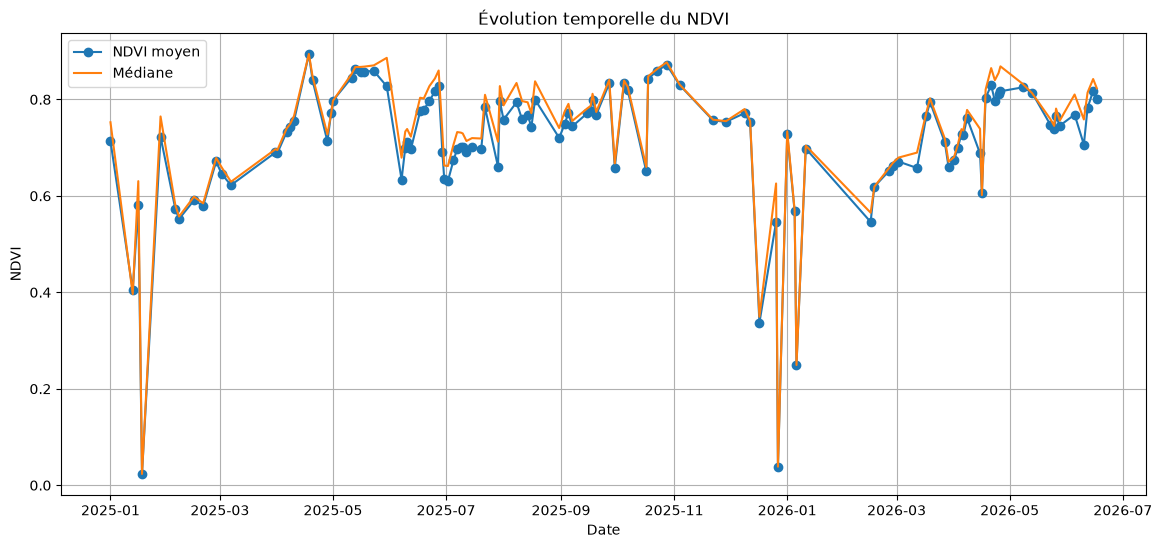

In [5]:
import matplotlib.pyplot as plt


plot_df = usable_df.sort_values(
    "acquisition_date"
)

plt.figure(figsize=(14, 6))

plt.plot(
    plot_df["acquisition_date"],
    plot_df["ndvi_mean"],
    marker="o",
    label="NDVI moyen",
)

plt.plot(
    plot_df["acquisition_date"],
    plot_df["ndvi_median"],
    label="Médiane",
)

plt.xlabel("Date")
plt.ylabel("NDVI")
plt.title("Évolution temporelle du NDVI")
plt.grid()
plt.legend()
plt.show()